In [1]:
import os
for dirname, _, filenames in os.walk('./archive'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


./archive\dataset_TSMC2014_NYC.csv
./archive\dataset_TSMC2014_TKY.csv


In [2]:
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from datetime import datetime, timedelta
import math
print("Setup Complete")

Setup Complete


In [3]:

def date_convert(date_to_convert):
    pru = datetime.datetime.strptime(date_to_convert, '%a %b %d %H:%M:%S +0000 %Y')+ datetime.timedelta(hours=-240//60)
    return pru.strftime('%b %d %Y %H:%M:%S')

def tzo_convert(tzo_to_convert):
    return  timedelta(hours=tzo_to_convert/60)

# Path of the file to read

nyc_filepath = "./archive/dataset_TSMC2014_NYC.csv"
custom_date_parser = lambda x: datetime.strptime(x, "%a %b %d %H:%M:%S +0000 %Y")

# Read the file into a variable nyc_data userId,venueId,venueCategoryId,venueCategory,latitude,longitude,timezoneOffset,utcTimestamp
nyc_data = pd.read_csv(nyc_filepath,parse_dates=['utcTimestamp'],date_parser=custom_date_parser)
nyc_data['utcTimestamp'] = pd.to_datetime(nyc_data['utcTimestamp'], format='%a %b %d %H:%M:%S +0000 %Y')

nyc_data


,userId,venueId,venueCategoryId,venueCategory,latitude,longitude,timezoneOffset,utcTimestamp
0,470,49bbd6c0f964a520f4531fe3,4bf58dd8d48988d127951735,Arts & Crafts Store,40.719810,-74.002581,-240,2012-04-03 18:00:09
1,979,4a43c0aef964a520c6a61fe3,4bf58dd8d48988d1df941735,Bridge,40.606800,-74.044170,-240,2012-04-03 18:00:25
2,69,4c5cc7b485a1e21e00d35711,4bf58dd8d48988d103941735,Home (private),40.716162,-73.883070,-240,2012-04-03 18:02:24
3,395,4bc7086715a7ef3bef9878da,4bf58dd8d48988d104941735,Medical Center,40.745164,-73.982519,-240,2012-04-03 18:02:41
4,87,4cf2c5321d18a143951b5cec,4bf58dd8d48988d1cb941735,Food Truck,40.740104,-73.989658,-240,2012-04-03 18:03:00
...,...,...,...,...,...,...,...,...
227423,688,3fd66200f964a52000e71ee3,4bf58dd8d48988d1e7931735,Music Venue,40.733596,-74.003139,-300,2013-02-16 02:29:11
227424,560,4bca32ff0687ef3be789dbcc,4bf58dd8d48988d16c941735,Burger Joint,40.745719,-73.993720,-300,2013-02-16 02:31:35
227425,945,50a77716e4b0b5a9492f6f56,4bf58dd8d48988d103941735,Home (private),40.854365,-73.883070,-300,2013-02-16 02:33:16
227426,671,4514efe0f964a520e7391fe3,4bf58dd8d48988d11d941735,Bar,40.735981,-74.029309,-300,2013-02-16 02:34:31


In [4]:
from datetime import time
#ajusto la hora con el timezoneoffset
nyc_data["utcTimestampOffset"] = nyc_data.utcTimestamp + nyc_data.timezoneOffset.apply(tzo_convert)
#block of time
nyc_data_time = nyc_data.utcTimestampOffset.dt.time 
morning_start = time(8,0,0)
noon_start = time(11,30,0)
afternoon_start = time(14,0,0)
night_start = time(17,30,0)
rest_start = time(22,0,0)
nyc_data["blockofday"] = nyc_data_time.apply(lambda x: 0 if x >= morning_start and x < noon_start else 1 if x >= noon_start and x < afternoon_start else 2 if x >= afternoon_start and x < night_start else 3 if x >= night_start and x < rest_start else 4)
#day of week
nyc_data["dayofweek"] = nyc_data.utcTimestampOffset.dt.weekday 
#is weekday?
nyc_data["isweekday"] = nyc_data['dayofweek'].apply(lambda x: 1 if x <= 4 else 0)
nyc_data

,userId,venueId,venueCategoryId,venueCategory,latitude,longitude,timezoneOffset,utcTimestamp,utcTimestampOffset,blockofday,dayofweek,isweekday
0,470,49bbd6c0f964a520f4531fe3,4bf58dd8d48988d127951735,Arts & Crafts Store,40.719810,-74.002581,-240,2012-04-03 18:00:09,2012-04-03 14:00:09,2,1,1
1,979,4a43c0aef964a520c6a61fe3,4bf58dd8d48988d1df941735,Bridge,40.606800,-74.044170,-240,2012-04-03 18:00:25,2012-04-03 14:00:25,2,1,1
2,69,4c5cc7b485a1e21e00d35711,4bf58dd8d48988d103941735,Home (private),40.716162,-73.883070,-240,2012-04-03 18:02:24,2012-04-03 14:02:24,2,1,1
3,395,4bc7086715a7ef3bef9878da,4bf58dd8d48988d104941735,Medical Center,40.745164,-73.982519,-240,2012-04-03 18:02:41,2012-04-03 14:02:41,2,1,1
4,87,4cf2c5321d18a143951b5cec,4bf58dd8d48988d1cb941735,Food Truck,40.740104,-73.989658,-240,2012-04-03 18:03:00,2012-04-03 14:03:00,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
227423,688,3fd66200f964a52000e71ee3,4bf58dd8d48988d1e7931735,Music Venue,40.733596,-74.003139,-300,2013-02-16 02:29:11,2013-02-15 21:29:11,3,4,1
227424,560,4bca32ff0687ef3be789dbcc,4bf58dd8d48988d16c941735,Burger Joint,40.745719,-73.993720,-300,2013-02-16 02:31:35,2013-02-15 21:31:35,3,4,1
227425,945,50a77716e4b0b5a9492f6f56,4bf58dd8d48988d103941735,Home (private),40.854365,-73.883070,-300,2013-02-16 02:33:16,2013-02-15 21:33:16,3,4,1
227426,671,4514efe0f964a520e7391fe3,4bf58dd8d48988d11d941735,Bar,40.735981,-74.029309,-300,2013-02-16 02:34:31,2013-02-15 21:34:31,3,4,1


Text(0, 0.5, 'visit counts')

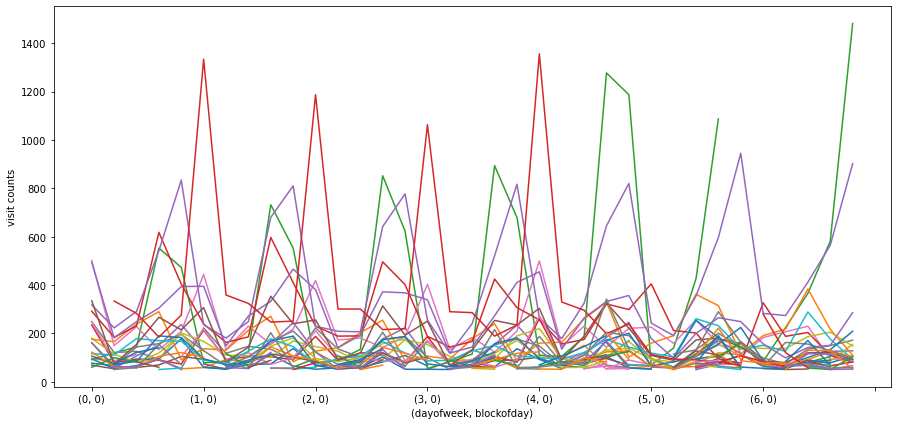

In [5]:
fig, ax = plt.subplots(figsize=(15,7))
# merged_data= merged_data[merged_data['category']!="Home (private)"]
pru = nyc_data.groupby([ 'dayofweek','blockofday','venueCategory']).venueId.agg([len])
# pru['percent'] = pru.groupby(['dayofweek','blockofday'])['len'].apply(lambda x: x / float(x.sum()))
pru2 =pru.query('len > 50 and len<1500')
# pru_sorted = pru2.sort_values(by='len')  # 按照len降序排列
# top5_categories = pru_sorted.index.get_level_values('venueCategory').unique()[:5]  # 取前5大的venueCategory

pru2.unstack().plot(ax=ax,legend=False)
# ax.legend(labels=pru_sorted.index.levels[2].tolist()[:5])
ax.set_xlabel('(dayofweek, blockofday)')
ax.set_ylabel('visit counts')

C:\Users\89660\AppData\Local\Temp/ipykernel_22064/3024771549.py:10: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  label_freq = pru3.reset_index().groupby(['isweekday', 'blockofday'])['venueCategory', 'len'].apply(lambda x: x.set_index('venueCategory')['len'].to_dict()).to_dict()


weekend morning


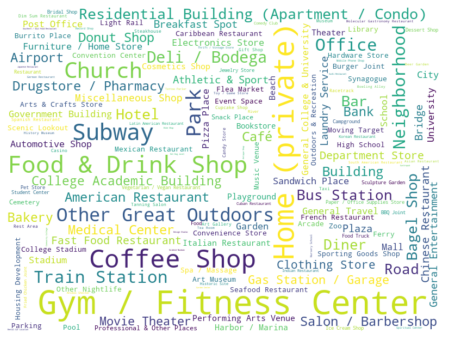

weekend noon


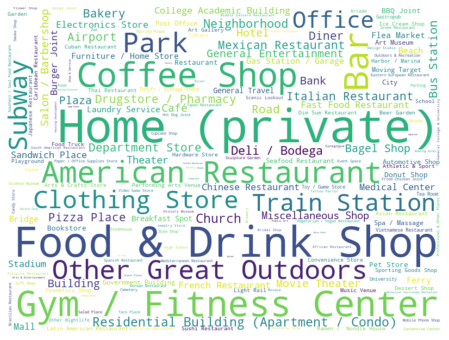

weekend afternoon


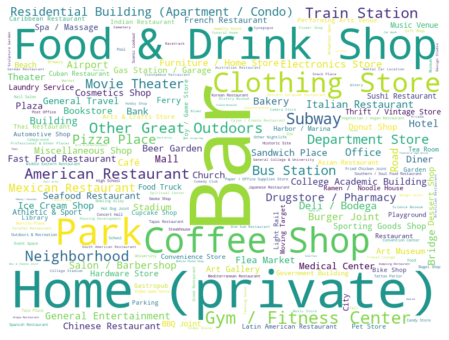

weekend night


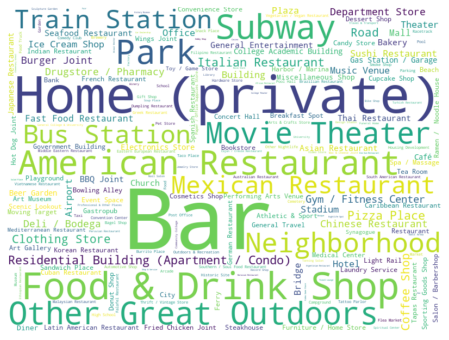

weekend rest


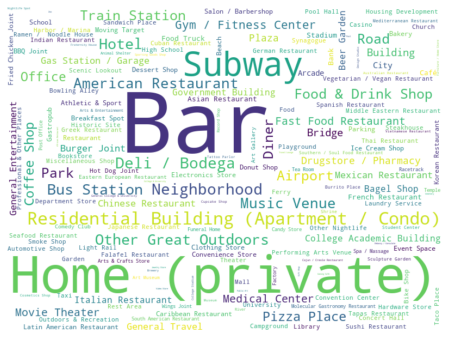

weekday morning


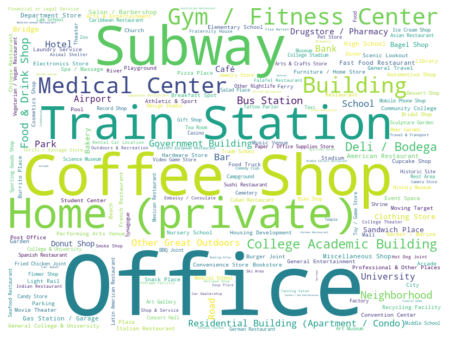

weekday noon


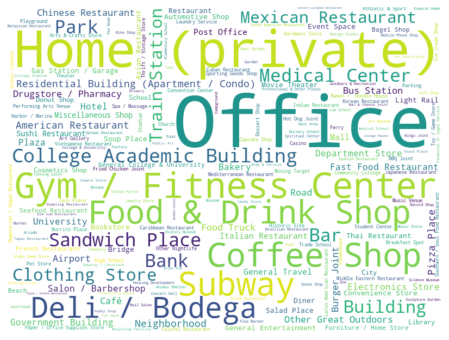

weekday afternoon


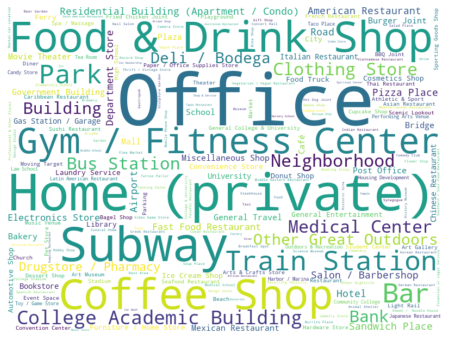

weekday night


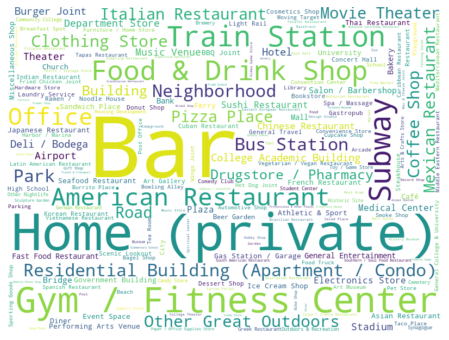

weekday rest


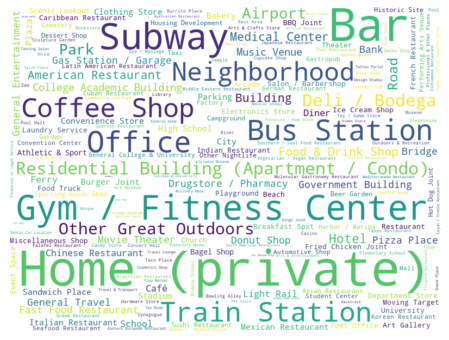

In [49]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
blockofday = {0:'morning',1:'noon',2:'afternoon',3:'night',4:'rest'}
dayofweek = {0:'Monday',1:'Tuesday',2:'Wednesday',3:'Thurthday',4:'Friday',5:'Saturday',6:'Sunday'}
isweekday = {0:'weekend',1:'weekday'}
# 计算每个标签下出现的频次
pru3 = nyc_data.groupby([ 'isweekday','blockofday','venueCategory']).venueId.agg([len])

label_freq = pru3.reset_index().groupby(['isweekday', 'blockofday'])['venueCategory', 'len'].apply(lambda x: x.set_index('venueCategory')['len'].to_dict()).to_dict()
# label_freq
# 生成词云
for label, freq_dict in label_freq.items():
    wordcloud = WordCloud(width=800, height=600, background_color='white',colormap='viridis').generate_from_frequencies(freq_dict)#, colormap='viridis'
    print(isweekday[label[0]], blockofday[label[1]])
    # 绘制词云
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(wordcloud, interpolation='bilinear')
    # ax.set_title("WordCloud of {}_{}".format(isweekday[label[0]], blockofday[label[1]]))
    ax.axis('off')
    plt.show()
    # 保存图形为SVG格式
    fig.savefig("./NYC/wordcloud/{}_{}.pdf".format(isweekday[label[0]], blockofday[label[1]]), format="pdf")

    # break
